In [13]:
import numpy as np
import numpy.linalg as la

A = np.array([1, 2, 3, 0, -4, 1, 0, 3, -1]).reshape(3,3)
b = np.array([2,2,1])

print(M)
print(la.det(M))

X = la.solve(A,b)

print(X)

print(A@A.T) # so not orthogonal

print(la.eigvals(A))

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
1.0
[ 38.  -3. -10.]
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[ 1.         -4.79128785 -0.20871215]


In [2]:
import numpy as np
import numpy.linalg as la

def rot_y(angle):
    angle = np.deg2rad(angle)
    R = np.array([np.cos(angle), 0, -np.sin(angle), 0, 1, 0, np.sin(angle), 0, np.cos(angle)]).reshape(3,3)
    return R

def rot_z(angle):
    angle = np.deg2rad(angle)
    R = np.array([np.cos(angle), np.sin(angle), 0, -np.sin(angle), np.cos(angle), 0, 0, 0, 1]).reshape(3,3)
    return R
    
M = rot_z(180-123) @ rot_y(90-27.4) @ rot_z(192.25)

print(M)

print(la.eigvals(M)) # has one at end

def r(angle, angle2):
    angle = np.deg2rad(angle)
    angle2 = np.deg2rad(angle2)
    r = np.array([np.cos(angle)*np.cos(angle2), np.cos(angle)*np.sin(angle2), np.sin(angle)]).reshape(3,1)
    return r

print(r(27.4, 192.25))

print(la.norm(r(27.4, 192.25)))

print(M@r(27.4, 192.25))

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]
1.0
[[2.77555756e-17]
 [5.55111512e-17]
 [1.00000000e+00]]


[[5.15978035e+00 4.29981696e+00 3.58318080e+00 2.98598400e+00
  2.48832000e+00 2.07360000e+00 1.72800000e+00 1.44000000e+00
  1.20000000e+00 1.00000000e+00]
 [5.12000000e+02 2.56000000e+02 1.28000000e+02 6.40000000e+01
  3.20000000e+01 1.60000000e+01 8.00000000e+00 4.00000000e+00
  2.00000000e+00 1.00000000e+00]
 [2.64396222e+04 8.52891037e+03 2.75126141e+03 8.87503681e+02
  2.86291510e+02 9.23521000e+01 2.97910000e+01 9.61000000e+00
  3.10000000e+00 1.00000000e+00]
 [6.18121840e+05 1.40482236e+05 3.19277810e+04 7.25631386e+03
  1.64916224e+03 3.74809600e+02 8.51840000e+01 1.93600000e+01
  4.40000000e+00 1.00000000e+00]
 [1.62841360e+06 3.32329306e+05 6.78223073e+04 1.38412872e+04
  2.82475249e+03 5.76480100e+02 1.17649000e+02 2.40100000e+01
  4.90000000e+00 1.00000000e+00]
 [7.42765874e+06 1.28063082e+06 2.20798417e+05 3.80686925e+04
  6.56356768e+03 1.13164960e+03 1.95112000e+02 3.36400000e+01
  5.80000000e+00 1.00000000e+00]
 [3.54520878e+07 5.13798374e+06 7.44635325e+05 1.07918163e

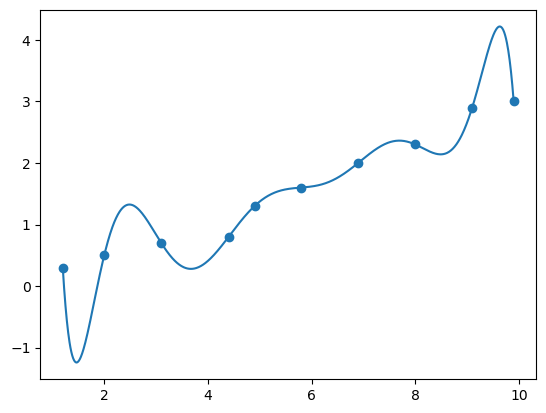

In [37]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

import numpy as np

list_x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])

B = []
n = len(list_x)

for x in list_x:
    row = []
    for power in range(n-1, -1, -1):
        row.append(x**power)
    B.append(row)

B = np.array(B)

print(B)

a = np.linalg.solve(A, y)

print(a)

fig, ax = plt.subplots()

ax.scatter(list_x, list_y)

x2 = np.linspace(min(list_x), max(list_x), 1000)

ax.plot(x2, np.polyval(a, x2))

What method would you like to use? (Linear, Quadratic, Cubic):  Cubic
What value of x between 1.2 and 9.9 would you like to evaluate?  6


The y coordinate for 6.0 in the plot is 1.65


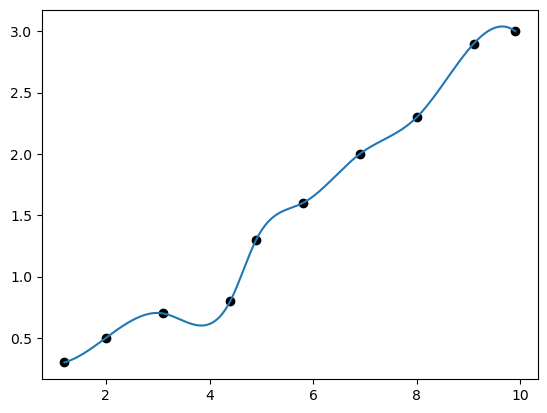

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.linalg as la
import scipy.interpolate as ip

class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        x_sort = np.sort(x)
        self.x_dense = np.linspace(min(x_sort), max(x_sort), 1000)
        self.linear = ip.interp1d(x, y, kind="linear")
        self.poly = ip.interp1d(x, y, kind="quadratic")
        self.cubic = ip.CubicSpline(x, y)
        self.fig, self.ax = plt.subplots()
    

    def plot_linear(self):
        ax = self.ax
        x_dense = self.x_dense
        y_dense = self.linear(x_dense)
        ax.plot(x_dense, y_dense)
        ax.scatter(x, y, color="black")
        ax.plot()

    def plot_poly(self):
        ax = self.ax
        x_dense = self.x_dense
        y_dense = self.poly(x_dense)
        ax.plot(x_dense, y_dense)
        ax.scatter(x, y, color="black")
        ax.plot()

    def plot_cubic(self):
        ax = self.ax
        x_dense = self.x_dense
        y_dense = self.cubic(x_dense)
        ax.plot(x_dense, y_dense)
        ax.scatter(x, y, color="black")
        ax.plot()

    def user_plot(self):
        choice = "hi"
        while choice != "linear" and choice != "quadratic" and choice != "cubic":
            choice = str.lower(input("What method would you like to use? (Linear, Quadratic, Cubic): "))
        user_x = 0
        while user_x < 1.2 or user_x > 9.9:
            user_x = float(input("What value of x between 1.2 and 9.9 would you like to evaluate? "))
        if choice == "linear":
            y_dense = self.linear(self.x_dense)
            for i in range(len(y_dense)):
                if round(user_x, 2) == round(self.x_dense[i], 2):
                    print(f"The y coordinate for {user_x} in the plot is {round(y_dense[i], 2)}")
                    break
            self.plot_linear()
        elif choice == "quadratic":
            y_dense = self.poly(self.x_dense)
            for i in range(len(y_dense)):
                if round(user_x, 2) == round(self.x_dense[i], 2):
                    print(f"The y coordinate for {user_x} in the plot is {round(y_dense[i], 2)}")
                    break
            self.plot_quadratic()
        elif choice == "cubic":
            y_dense = self.cubic(self.x_dense)
            for i in range(len(y_dense)):
                if round(user_x, 2) == round(self.x_dense[i], 2):
                    print(f"The y coordinate for {user_x} in the plot is {round(y_dense[i], 2)}")
                    break
            self.plot_cubic()
        else:
            print("how did you get here?")
            
    

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

graph1 = interpolation(x, y)
graph1.user_plot()

In [5]:
import numpy as np

def bilinearIP(I, col, row):
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)
    
I = np.array([[2.0,4.1], [2.5,3.8]])
print(I)

row_y = 0.7
col_x = 0.2

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} at x, y={col_x},{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")

[[2.  4.1]
 [2.5 3.8]]
The interpolated intensity at i,j=0.7,0.2 at x, y=0.2,0.7 is 2.658000


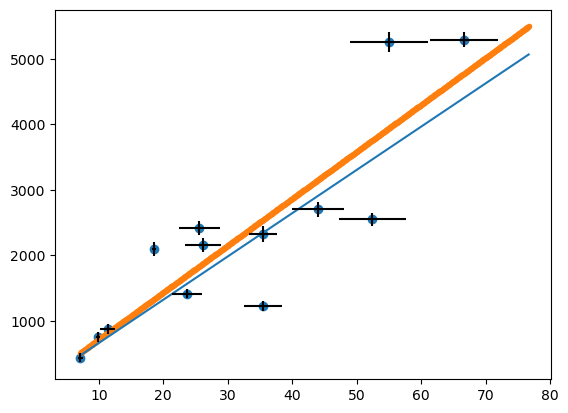

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as so

def hubble_law(d, H0):
    return H0 * d

def H_sqr(H0, d, v):
    v_model = H0 * d
    return v - v_model

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

d = data[0::4]
v = data[1::4]
d_err = data[2::4]
v_err = data[3::4]

fig, ax = plt.subplots()
popt, pcov = so.curve_fit(f=hubble_law, xdata=d, ydata=v, sigma=v_err)
x_dense = np.linspace(min(d), max(d)+10, 1000)
y_dense = popt*(x_dense)
ax.plot(x_dense, y_dense, label="curve fit")
ax.scatter(d,v)
ax.errorbar(d, v, xerr=d_err, yerr=v_err, ls="none", color="black")

popt_leastsq, flag = so.leastsq(func=H_sqr, x0=70, args=(d, v))
x_srt = np.linspace(min(d), max(d)+10, 1000)
y_srt = popt_leastsq*(x_srt)
ax.scatter(x_srt, y_srt, label="least squares fit", marker=".")